# **Lexicon-Based Sentiment Analysis**

In [ ]:
import pandas as pd
import re

# -----------------------------
# 1. Load datasets
# -----------------------------
lexicon = pd.read_csv("lexicon.csv")
comments = pd.read_csv("fbsaya_comments.csv")

In [ ]:
# -----------------------------
# 2. Prepare lexicon dictionary
# -----------------------------
# normalize words to lowercase
lexicon["word"] = lexicon["word"].str.lower().str.strip()

# build dictionary: word -> sentiment score
lex_dict = dict(zip(lexicon["word"], lexicon["sentiment score"]))

# optional: also store categorical sentiment
lex_sentiment = dict(zip(lexicon["word"], lexicon["sentiment"]))

In [ ]:
# -----------------------------
# 3. Preprocessing & Tokenization
# -----------------------------
def preprocess(text):
    if pd.isna(text):
        return ""
    # lowercase, remove URLs, non-alphanumeric (keep ñ, vowels with diacritics)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zñáéíóúü\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

In [ ]:
# -----------------------------
# 4. Sentiment Scoring Function
# -----------------------------
NEGATORS = {"indi", "wala", "hindi", "dili"}  # negation words
INTENSIFIERS = {"gid": 1.5, "kaayo": 1.5, "gidman": 1.3}

def compute_sentiment(tokens):
    score = 0.0
    i = 0
    while i < len(tokens):
        tok = tokens[i]
        mult = 1.0

        # check intensifiers
        if tok in INTENSIFIERS and i + 1 < len(tokens):
            i += 1
            next_tok = tokens[i]
            s = lex_dict.get(next_tok, 0)
            score += s * INTENSIFIERS[tok]
            i += 1
            continue

        # check negation
        if tok in NEGATORS and i + 1 < len(tokens):
            i += 1
            next_tok = tokens[i]
            s = lex_dict.get(next_tok, 0)
            score -= s  # flip polarity
            i += 1
            continue

        # regular word lookup
        s = lex_dict.get(tok, 0)
        score += s
        i += 1

    return score

def label_from_score(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
# -----------------------------
# 5. Apply to FB comments
# -----------------------------
comments["clean_text"] = comments["text"].apply(preprocess)
comments["tokens"] = comments["clean_text"].apply(tokenize)
comments["sentiment_score"] = comments["tokens"].apply(compute_sentiment)
comments["sentiment"] = comments["sentiment_score"].apply(label_from_score)

In [ ]:
# -----------------------------
# 6. Save results
# -----------------------------
comments.to_csv("fb_comments_with_sentiment.csv", index=False)

print("✅ Sentiment analysis done! Results saved to fb_comments_with_sentiment.csv")
print(comments[["text", "tokens", "sentiment_score", "sentiment"]].head())

✅ Sentiment analysis done! Results saved to fb_comments_with_sentiment.csv
                                                text  \
0  Ngaa si Duterte man Kay ginpa preso\nNato sya ...   
1  Wala man bala da dapat politika ngaa ara da ya...   
2                                   Duterte pa rin 👊   
3  Mag daog c sara sa 2028 dulaun nya nlang ni mg...   
4  Na preso na si duterte...focus kamo sa mga kaw...   

                                              tokens  sentiment_score  \
0  [ngaa, si, duterte, man, kay, ginpa, preso, na...            0.000   
1  [wala, man, bala, da, dapat, politika, ngaa, a...            0.361   
2                                 [duterte, pa, rin]            0.000   
3  [mag, daog, c, sara, sa, dulaun, nya, nlang, n...            0.402   
4  [na, preso, na, si, duterte, focus, kamo, sa, ...           -0.791   

  sentiment  
0   Neutral  
1  Positive  
2   Neutral  
3  Positive  
4  Negative  


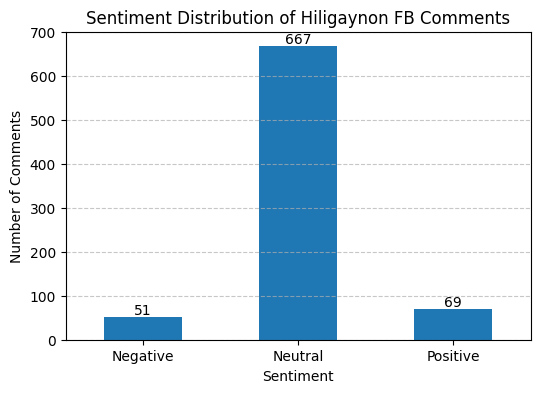

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# 7. Sentiment Distribution
# -----------------------------
sent_counts = comments["sentiment"].value_counts().sort_index()

plt.figure(figsize=(6,4))
ax = sent_counts.plot(kind="bar")

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Sentiment Distribution of Hiligaynon FB Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [ ]:
from collections import Counter

all_tokens = [tok for tokens in comments["tokens"] for tok in tokens]
word_counts = Counter(all_tokens)

# Top positive words
pos_words = [(w, c) for w, c in word_counts.items() if lex_dict.get(w, 0) > 0]
neg_words = [(w, c) for w, c in word_counts.items() if lex_dict.get(w, 0) < 0]

print("Top Positive Words:", sorted(pos_words, key=lambda x: -x[1])[:10])
print("Top Negative Words:", sorted(neg_words, key=lambda x: -x[1])[:10])

NameError: name 'comments' is not defined

# **Topic/Theme Extraction**

### **BERTopic**

In [ ]:
!pip install bertopic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 8.7 MB/s eta 0:00:00


In [ ]:
!python -m spacy download xx_ent_wiki_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 19.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# fb_comments_all_clustering_lexicon.py
# Usage: python fb_comments_all_clustering_lexicon.py
# Requires:
#   pip install sentence-transformers hdbscan scikit-learn pandas spacy
#   python -m spacy download xx_ent_wiki_sm   # or en_core_web_sm

import os, re
import pandas as pd
import numpy as np
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
import hdbscan
from sklearn.metrics.pairwise import cosine_similarity
import spacy

# -------- CONFIG --------
INPUT_CSV = "/fbsaya_comments.csv"
LEXICON_CSV = "/NLP Lexicon - Merged_csv.csv"
TEXT_COLUMN = "text"
OUTPUT_DIR = "hybrid_output"
TOP_N_WORDS = 20  # pull more, then filter by lexicon
KMEANS_CLUSTERS = 5
AGGLO_CLUSTERS = 5
COSINE_THRESHOLD = 0.7
# ------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- PREPROCESS --------
def preprocess(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zñáéíóúü0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# -------- LOAD DATA --------
df = pd.read_csv(INPUT_CSV, dtype={TEXT_COLUMN: str})
df["clean_text"] = df[TEXT_COLUMN].apply(preprocess)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
texts = df["clean_text"].tolist()
print(f"Loaded {len(texts)} comments.")

# -------- EMBEDDINGS --------
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(texts, show_progress_bar=True)

# -------- LEXICON --------
lex_df = pd.read_csv(LEXICON_CSV)
lexicon_map = {row["word"]: row for _, row in lex_df.iterrows()}
lexicon_words = set(lexicon_map.keys())
print(f"Loaded {len(lexicon_words)} lexicon words.")

# -------- SPACY --------
try:
    nlp = spacy.load("xx_ent_wiki_sm")
except OSError:
    print("[WARN] Multilingual model not found, falling back to English (en_core_web_sm)")
    nlp = spacy.load("en_core_web_sm")

def annotate_word(word):
    """Return lexicon metadata if word is in lexicon, else None."""
    if word in lexicon_map:
        row = lexicon_map[word]
        return {
            "word": word,
            "pos": row.get("pos_word", None),
            "meaning": row.get("meaning", None)
        }
    return None

# -------- CLUSTER ANALYSIS --------
def analyze_clusters(labels, method):
    df_out = df.copy()
    df_out["cluster"] = labels
    df_out.to_csv(os.path.join(OUTPUT_DIR, f"comments_with_clusters_{method}.csv"), index=False)

    cluster_summaries = []
    for cluster_id in sorted(set(labels)):
        if cluster_id == -1:
            continue
        cluster_docs = df_out[df_out["cluster"] == cluster_id]["clean_text"].tolist()

        # Entities
        ents = []
        for text in cluster_docs:
            doc = nlp(text)
            ents.extend([(ent.text, ent.label_) for ent in doc.ents])
        ent_counts = Counter([e[0] for e in ents])

        # Word frequencies
        words = [w for doc in cluster_docs for w in doc.split()]
        word_counts = Counter(words).most_common(TOP_N_WORDS)

        # Filter + annotate only lexicon words
        annotated_words = []
        for w, freq in word_counts:
            ann = annotate_word(w)
            if ann:  # keep only lexicon words
                ann["topic"] = cluster_id
                ann["freq"] = freq
                ann["method"] = method
                annotated_words.append(ann)

        cluster_summaries.extend(annotated_words)

        # Print summary
        print(f"\n--- {method.upper()} Cluster {cluster_id} ({len(cluster_docs)} docs) ---")
        print("Top Entities:", ent_counts.most_common(5))
        if annotated_words:
            print("Lexicon words:",
                  ", ".join([f"{a['word']} [{a['pos']}]" for a in annotated_words]))
        else:
            print("(no lexicon words found)")

    summary_df = pd.DataFrame(cluster_summaries)
    summary_df.to_csv(os.path.join(OUTPUT_DIR, f"cluster_top_words_lexicon_{method}.csv"), index=False)

# -------- RUN ALL METHODS --------

# 1. HDBSCAN
print("\n[1] HDBSCAN clustering...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=1, metric="euclidean")
labels_hdb = clusterer.fit_predict(embeddings)
analyze_clusters(labels_hdb, "hdbscan")

# 2. KMeans
print("\n[2] KMeans clustering...")
km = KMeans(n_clusters=KMEANS_CLUSTERS, random_state=42)
labels_km = km.fit_predict(embeddings)
analyze_clusters(labels_km, "kmeans")

# 3. Agglomerative
print("\n[3] Agglomerative clustering...")
agg = AgglomerativeClustering(n_clusters=AGGLO_CLUSTERS)
labels_agg = agg.fit_predict(embeddings)
analyze_clusters(labels_agg, "agglomerative")

# 4. Cosine similarity grouping
print("\n[4] Cosine similarity threshold grouping...")
sim_matrix = cosine_similarity(embeddings)
labels_cosine = -1 * np.ones(len(texts), dtype=int)
cluster_id = 0
visited = set()

for i in range(len(texts)):
    if i in visited:
        continue
    neighbors = np.where(sim_matrix[i] > COSINE_THRESHOLD)[0]
    if len(neighbors) > 1:
        labels_cosine[neighbors] = cluster_id
        visited.update(neighbors)
        cluster_id += 1

analyze_clusters(labels_cosine, "cosine")

print("\n✅ All clustering methods complete. Results in:", OUTPUT_DIR)


Loaded 776 comments.


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Loaded 5191 lexicon words.
[WARN] Multilingual model not found, falling back to English (en_core_web_sm)

[1] HDBSCAN clustering...

--- HDBSCAN Cluster 0 (684 docs) ---
Top Entities: [('kamo', 21), ('marcos', 18), ('kayo', 16), ('mag', 13), ('mga', 13)]
Lexicon words: na [particle], sa [adverb], si [particle], pa [particle], ni [particle], nga [particle]

--- HDBSCAN Cluster 1 (11 docs) ---
Top Entities: [('meowww meow', 1), ('meooowwwwwwwwwwwww', 1)]
(no lexicon words found)

[2] KMeans clustering...

--- KMEANS Cluster 0 (108 docs) ---
Top Entities: [('mag', 6), ('kayo', 5), ('mga kabataan', 4), ('du30', 4), ('mga kawatan', 3)]
Lexicon words: sa [adverb], na [particle], si [particle], pa [particle], ni [particle]

--- KMEANS Cluster 1 (89 docs) ---
Top Entities: [('nyu', 4), ('kamo', 4), ('marcos', 4), ('kag', 3), ('nila', 3)]
Lexicon words: na [particle], sa [adverb], nga [particle], pa [particle], ni [particle], si [particle]

--- KMEANS Cluster 2 (220 docs) ---
Top Entities: [('k

In [ ]:
# fb_comments_bertopic_lexicon_vocab.py
# Requires:
#   pip install bertopic[all] sentence-transformers pandas scikit-learn umap-learn hdbscan
#   python -m spacy download xx_ent_wiki_sm   # optional for POS fallback

import re
import pandas as pd
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import umap

# -------- CONFIG --------
INPUT_CSV = "/fbsaya_comments.csv"
LEXICON_CSV = "/NLP Lexicon - Merged_csv.csv"
TEXT_COLUMN = "text"
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
N_TOP_WORDS = 20   # pull more, filter by lexicon
REP_DOCS = 3

# -------- Preprocess --------
def preprocess(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zñáéíóúü0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# -------- Main --------
def run_pipeline():
    # Load comments
    df = pd.read_csv(INPUT_CSV, dtype={TEXT_COLUMN: str})
    df["clean_text"] = df[TEXT_COLUMN].apply(preprocess)
    texts = df[df["clean_text"].str.strip() != ""]["clean_text"].tolist()
    print(f"Loaded {len(texts)} comments.")

    # Load lexicon
    lex_df = pd.read_csv(LEXICON_CSV)
    lexicon_words = lex_df["word"].dropna().unique().tolist()
    lexicon_map = {row["word"]: row for _, row in lex_df.iterrows()}
    print(f"Loaded {len(lexicon_words)} lexicon words.")

    # Embeddings
    embedder = SentenceTransformer(EMBEDDING_MODEL)
    embeddings = embedder.encode(texts, show_progress_bar=True)

    # Vectorizer restricted to lexicon vocabulary
    vectorizer = CountVectorizer(vocabulary=lexicon_words)

    # UMAP reducer
    umap_model = umap.UMAP(n_neighbors=10, n_components=5, min_dist=0.1, random_state=42)

    # BERTopic
    topic_model = BERTopic(
        embedding_model=embedder,
        vectorizer_model=vectorizer,
        umap_model=umap_model,
        nr_topics="50",
        calculate_probabilities=True,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(texts, embeddings)

    # -------- Print topics (lexicon only) --------
    for t in topic_model.get_topics().keys():
        if t == -1:
            continue
        raw_top_words = [w for w, _ in topic_model.get_topic(t)[:N_TOP_WORDS]]
        lexicon_words_in_topic = []
        for w in raw_top_words:
            if w in lexicon_map:
                row = lexicon_map[w]
                lexicon_words_in_topic.append(f"{w} [{row['pos_word']} ]")

        print(f"\n--- Topic {t} ---")
        if lexicon_words_in_topic:
            print("Lexicon words:", ", ".join(lexicon_words_in_topic))
        else:
            print("(no lexicon words found)")

        docs = [texts[i] for i, label in enumerate(topics) if label == t][:REP_DOCS]
        for d in docs:
            print("  •", d)

    print("\n✅ Done.")

if __name__ == "__main__":
    run_pipeline()


Loaded 776 comments.
Loaded 5191 lexicon words.


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

2025-09-26 10:01:54,617 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-09-26 10:01:56,612 - BERTopic - Dimensionality - Completed ✓
2025-09-26 10:01:56,613 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-26 10:01:56,666 - BERTopic - Cluster - Completed ✓
2025-09-26 10:01:56,667 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2025-09-26 10:01:56,698 - BERTopic - Representation - Completed ✓
2025-09-26 10:01:56,699 - BERTopic - Topic reduction - Reducing number of topics
2025-09-26 10:01:56,709 - BERTopic - Representation - Fine-tuning topics using representation models.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples


--- Topic 0 ---
Lexicon words: na [particle ], sa [adverb ], si [particle ], pa [particle ], ni [particle ], nga [particle ], may [verb ], dapat [adjective ], eh [particle ], kawatan [noun ]
  • ngaa si duterte man kay ginpa preso nato sya ni marcos anu gina singgit mo da nami baba mo ehh ang mga kurap si martin at si zaldy co nga paryente mo bala nga hangag kaw indi mo pag e singgit ila ngalan ma ngo
  • wala man bala da dapat politika ngaa ara da ya ang kabataan party list haw kag may mga ttarp pa cla daw hinaslo haw nd na ya personal interest tni wala streamer sang bsan ano nga grupo politika kn amo na ila gnahambal hinaslo personal interest na ina inyo ya
  • duterte pa rin

--- Topic 1 ---
(no lexicon words found)
  • meow meow
  • meow meow meow
  • meow meow meow meow meow

✅ Done.


### **LDA**

In [ ]:
import pandas as pd
import re
from collections import Counter

# Load your file (replace with your actual filename if needed)
file_path = "fbsaya_comments.csv"
comments = pd.read_csv(file_path)

# Preprocessing function (basic cleaning, keep only letters + accents + ñ)
def preprocess(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-zñáéíóúü\s]", " ", text)
    return text.strip()

# Clean text
comments["clean_text"] = comments["text"].fillna("").apply(preprocess)

# Tokenize
all_tokens = []
for row in comments["clean_text"]:
    all_tokens.extend(row.split())

# Count frequencies
token_counts = Counter(all_tokens)

# Put into DataFrame
stopword_candidates = pd.DataFrame(token_counts.most_common(), columns=["word", "count"])

# Save to CSV
output_path = "stopword_candidates.csv"
stopword_candidates.to_csv(output_path, index=False)

print(f"Stopword candidates saved to: {output_path}")

Stopword candidates saved to: stopword_candidates.csv



=== LDA Topics ===
Topic 0: kabataan, duterte, partylist, panahon, control, marcos, romualdez, panggulo, putang, digong
Topic 1: hahaha, duterte, lipunan, parente, tapos, malakas, bansa, walang, ngayon, martin
Topic 2: panagutin, isigaw, marcos, martin, walang, hahaha, buwaya, pinoy, pulis, marcosresign
Topic 3: duterte, pinsan, hahaha, president, marcos, singgit, romualdez, kulang, pulos, priso
Topic 4: marcos, duterte, resign, panagutin, bongbong, gobyerno, romualdez, pilipinas, project, ibang
Topic 5: marcos, duterte, panagutin, leader, kawatan, kulang, inday, tapos, digong, tatay
Topic 6: duterte, kabataan, corrupt, hahahaha, focus, corruption, mango, preso, iloilo, walang
Topic 7: duterte, marcos, panagutin, bugok, kahit, kurap, magnanakaw, magkano, labot, pauwiin
Topic 8: duterte, hahaha, presidente, congressman, marcos, kulot, pilipinas, block, baliw, million
Topic 9: bangag, bayaran, pilipino, ngayon, abnormal, duterte, isigaw, kaung, klaro, hangag


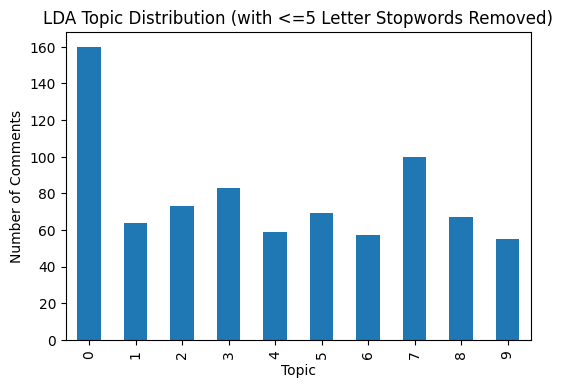

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# === Step 1: Load stopwords from CSV (custom logic) ===
stopwords_df = pd.read_csv("stopword_candidates.csv")

hiligaynon_stopwords = stopwords_df[
    (stopwords_df["word"].str.len() < 5) |
    ((stopwords_df["word"].str.len() <= 5) & (stopwords_df["count"] > 10))
]["word"].tolist()


# === Step 2: Preprocessing ===
def preprocess(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-zñáéíóúü\s]", " ", text)  # keep letters + ñ accents
    tokens = text.split()
    tokens = [t for t in tokens if t not in hiligaynon_stopwords]
    return " ".join(tokens)

# Apply preprocessing
comments["clean_text_preprocessed"] = comments["clean_text"].fillna("").apply(preprocess)

# === Step 3: Vectorize text ===
count_vectorizer = CountVectorizer(
    max_features=2000,
    stop_words=hiligaynon_stopwords
)
X_counts = count_vectorizer.fit_transform(comments["clean_text_preprocessed"])

# === Step 4: Run LDA ===
num_topics = 10  # fixed for comparison with BERTopic reduced
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(X_counts)

# === Step 5: Display top words per topic ===
terms = count_vectorizer.get_feature_names_out()
print("\n=== LDA Topics ===")
for idx, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-10:][::-1]
    top_words = [terms[i] for i in top_idx]
    print(f"Topic {idx}: {', '.join(top_words)}")

# === Step 6: Assign each comment its most likely topic ===
topic_assignments = lda.transform(X_counts).argmax(axis=1)
comments["lda_topic"] = topic_assignments

# === Step 7: Plot topic distribution ===
plt.figure(figsize=(6,4))
comments["lda_topic"].value_counts().sort_index().plot(kind="bar")
plt.title("LDA Topic Distribution (with <=5 Letter Stopwords Removed)")
plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.show()

In [ ]:
comments.to_csv("fb_comments_with_topics_clusters.csv", index=False)
print("✅ Combined dataset saved to fb_comments_with_topics_clusters.csv")

✅ Combined dataset saved to fb_comments_with_topics_clusters.csv


In [ ]:
# fb_comments_lda_lexicon.py
# Requires:
#   pip install gensim pandas scikit-learn spacy
#   python -m spacy download xx_ent_wiki_sm

import re
import pandas as pd
import gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel
import spacy

# -------- CONFIG --------
INPUT_CSV = "/fbsaya_comments.csv"
LEXICON_CSV = "/NLP Lexicon - Merged_csv.csv"
TEXT_COLUMN = "text"
N_TOPICS = 5
N_WORDS = 10

# -------- Preprocess --------
def preprocess(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zñáéíóúü0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# -------- Load Data --------
df = pd.read_csv(INPUT_CSV, dtype={TEXT_COLUMN: str})
df["tokens"] = df[TEXT_COLUMN].apply(preprocess)
texts = df["tokens"].tolist()
print(f"Loaded {len(texts)} comments.")

# -------- Load Lexicon --------
lex_df = pd.read_csv(LEXICON_CSV)
lexicon_words = set(lex_df["word"].dropna().tolist())
lexicon_map = {row["word"]: row for _, row in lex_df.iterrows()}
print(f"Loaded {len(lexicon_words)} lexicon words.")

# -------- Filter tokens to lexicon vocabulary --------
filtered_texts = [[w for w in doc if w in lexicon_words] for doc in texts]

# -------- Build Dictionary & Corpus --------
dictionary = corpora.Dictionary(filtered_texts)
corpus = [dictionary.doc2bow(text) for text in filtered_texts]

# -------- Train LDA --------
lda = LdaModel(corpus=corpus, num_topics=N_TOPICS, id2word=dictionary, passes=15, random_state=42)

# -------- Print Topics (lexicon-only words) --------
for i, topic in lda.show_topics(num_topics=N_TOPICS, num_words=N_WORDS, formatted=False):
    print(f"\n--- Topic {i} ---")
    words = []
    for word, prob in topic:
        if word in lexicon_map:
            row = lexicon_map[word]
            words.append(f"{word} [{row['pos_word']}]")
    if words:
        print("Lexicon words:", ", ".join(words))
    else:
        print("(no lexicon words found)")


Loaded 787 comments.
Loaded 5191 lexicon words.

--- Topic 0 ---
Lexicon words: na [particle], ngaa [adverb], mango [adjective], basura [noun], abi [verb], dira [adverb], subong [adverb], damo [verb], gihapon [adverb], ngalan [noun]

--- Topic 1 ---
Lexicon words: may [verb], bobo [noun], bayad [noun], nga [particle], ara [noun], utang [verb], utak [noun], kawatan [noun], pa [particle], amo [noun]

--- Topic 2 ---
Lexicon words: si [particle], nga [particle], gago [adjective], o [particle], ta [pronoun], a [particle], tatay [noun], indi [interjection], ulo [noun], init [noun]

--- Topic 3 ---
Lexicon words: sa [adverb], na [particle], nga [particle], pa [particle], o [particle], si [particle], kawatan [noun], utok [noun], anu [verb], ni [particle]

--- Topic 4 ---
Lexicon words: ni [particle], pa [particle], dapat [adjective], na [particle], eh [particle], alam [noun], si [particle], basta [adjective], a [particle], baton [verb]


In [ ]:
# fb_comments_lda_lexicon_distribution_overall_nomean.py
# Requires:
#   pip install gensim pandas scikit-learn spacy

import re
import pandas as pd
import gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel
import numpy as np

# -------- CONFIG --------
INPUT_CSV = "/fbsaya_comments.csv"
LEXICON_CSV = "/NLP Lexicon - Merged_csv.csv"
TEXT_COLUMN = "text"
N_TOPICS = 5
N_WORDS = 10

# -------- Preprocess --------
def preprocess(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zñáéíóúü0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# -------- Load Data --------
df = pd.read_csv(INPUT_CSV, dtype={TEXT_COLUMN: str})
df["tokens"] = df[TEXT_COLUMN].apply(preprocess)
texts = df["tokens"].tolist()
print(f"Loaded {len(texts)} comments.")

# -------- Load Lexicon --------
lex_df = pd.read_csv(LEXICON_CSV)
lexicon_words = set(lex_df["word"].dropna().tolist())
lexicon_map = {row["word"]: row for _, row in lex_df.iterrows()}
print(f"Loaded {len(lexicon_words)} lexicon words.")

# -------- Filter tokens to lexicon vocabulary --------
filtered_texts = [[w for w in doc if w in lexicon_words] for doc in texts]

# -------- Build Dictionary & Corpus --------
dictionary = corpora.Dictionary(filtered_texts)
corpus = [dictionary.doc2bow(text) for text in filtered_texts]

# -------- Train LDA --------
lda = LdaModel(corpus=corpus, num_topics=N_TOPICS, id2word=dictionary, passes=15, random_state=42)

# -------- Print Topics with Word Distribution --------
for i, topic in lda.show_topics(num_topics=N_TOPICS, num_words=N_WORDS, formatted=False):
    print(f"\n--- Topic {i} ---")
    found = False
    for word, weight in topic:
        if word in lexicon_map:
            row = lexicon_map[word]
            pos = row.get("pos_word", "")
            label = f"{word} [{pos}]" if pos else word
            print(f"{label} ({weight:.3f})")
            found = True
    if not found:
        print("(no lexicon words found)")

# -------- Document-Topic Distribution --------
print("\n\n=== Document-Topic Distributions (sample) ===")
doc_topics = []
all_distributions = []

for idx, bow in enumerate(corpus):
    topic_dist = lda.get_document_topics(bow, minimum_probability=0.0)
    sorted_dist = sorted(topic_dist, key=lambda x: -x[1])
    top_topic, top_prob = sorted_dist[0]
    doc_topics.append((idx, top_topic, top_prob, sorted_dist))
    all_distributions.append([prob for tid, prob in sorted_dist])

# Save per-document distributions
dist_df = pd.DataFrame([
    {
        "doc_id": idx,
        "text": df.loc[idx, TEXT_COLUMN],
        "top_topic": top_topic,
        "top_prob": top_prob,
        "distribution": str(sorted_dist)
    }
    for idx, top_topic, top_prob, sorted_dist in doc_topics
])
dist_df.to_csv("lda_doc_topic_distribution.csv", index=False)
print("✅ Saved per-document topic distributions to lda_doc_topic_distribution.csv")

# -------- Overall Topic Distribution --------
overall_dist = np.mean(all_distributions, axis=0)

print("\n=== Overall Topic Distribution (across all docs) ===")
for tid, prob in enumerate(overall_dist):
    print(f"Topic {tid}: {prob:.3f}")

overall_df = pd.DataFrame({
    "topic": list(range(N_TOPICS)),
    "probability": overall_dist
})
overall_df.to_csv("lda_overall_topic_distribution.csv", index=False)
print("✅ Saved overall topic distribution to lda_overall_topic_distribution.csv")


Loaded 787 comments.
Loaded 5191 lexicon words.

--- Topic 0 ---
na [particle] (0.136)
ngaa [adverb] (0.119)
mango [adjective] (0.069)
basura [noun] (0.056)
abi [verb] (0.056)
dira [adverb] (0.055)
subong [adverb] (0.042)
damo [verb] (0.029)
gihapon [adverb] (0.029)
ngalan [noun] (0.021)

--- Topic 1 ---
may [verb] (0.191)
bobo [noun] (0.096)
bayad [noun] (0.080)
nga [particle] (0.067)
ara [noun] (0.062)
utang [verb] (0.044)
utak [noun] (0.043)
kawatan [noun] (0.040)
pa [particle] (0.038)
amo [noun] (0.034)

--- Topic 2 ---
si [particle] (0.450)
nga [particle] (0.141)
gago [adjective] (0.051)
o [particle] (0.047)
ta [pronoun] (0.026)
a [particle] (0.025)
tatay [noun] (0.018)
indi [interjection] (0.015)
ulo [noun] (0.013)
init [noun] (0.013)

--- Topic 3 ---
sa [adverb] (0.353)
na [particle] (0.340)
nga [particle] (0.037)
pa [particle] (0.033)
o [particle] (0.015)
si [particle] (0.015)
kawatan [noun] (0.014)
utok [noun] (0.011)
anu [verb] (0.009)
ni [particle] (0.008)

--- Topic 4 ---
n

In [ ]:
!pip install gensim pandas scikit-learn spacy
!python -m spacy download xx_ent_wiki_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 20.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
  Atte

^C


# **Domain-Specific Sentiment Lexicon Expansion (ignore)**

In [ ]:
import pandas as pd
import re
from collections import Counter
from itertools import chain

# Load data
comments = pd.read_csv("fb_comments_with_topics_clusters.csv")
lexicon = pd.read_csv("lexicon.csv")

In [ ]:
# Preprocess
def preprocess(text):
    if pd.isna(text):
        return []
    text = text.lower()
    text = re.sub(r"[^a-zñáéíóúü\s]", " ", text)
    return text.strip().split()

comments["tokens"] = comments["clean_text"].apply(preprocess)

In [ ]:
# Build vocabulary from comments
all_tokens = list(chain.from_iterable(comments["tokens"]))
word_freq = Counter(all_tokens)

# Words already in lexicon
lex_words = set(lexicon["word"].str.lower())

# Candidate words (frequent but not in lexicon)
candidates = [w for w, f in word_freq.items() if f > 5 and w not in lex_words]  # threshold=5
print("Sample candidates:", candidates[:20])

Sample candidates: ['duterte', 'man', 'kay', 'preso', 'sya', 'marcos', 'gina', 'singgit', 'mo', 'da', 'ang', 'mga', 'kurap', 'martin', 'at', 'zaldy', 'co', 'hangag', 'pag', 'e']


In [ ]:
# --- Step 2: Estimate polarity using seed words ---
positive_seeds = {"maayo", "bendisyon", "kalipay", "palangga", "grasia"}  # positive seeds
negative_seeds = {"sala", "kasubo", "malaut", "kawatan", "kapahamakan"}  # negative seeds

def estimate_polarity(candidates, tokens):
    cooc_pos, cooc_neg = Counter(), Counter()
    window = 5  # context window size

    for comment in tokens:
        for i, word in enumerate(comment):
            if word in candidates:
                left = comment[max(0, i-window):i]
                right = comment[i+1:i+window]
                context = left + right
                if any(w in context for w in positive_seeds):
                    cooc_pos[word] += 1
                if any(w in context for w in negative_seeds):
                    cooc_neg[word] += 1

    expanded = []
    for w in candidates:
        pos, neg = cooc_pos[w], cooc_neg[w]
        score = pos - neg  # simple heuristic
        sentiment = "Positive" if score > 0 else "Negative" if score < 0 else "Neutral"
        expanded.append((w, score, sentiment))

    return pd.DataFrame(expanded, columns=["word", "sentiment_score", "sentiment"])

expanded_lexicon = estimate_polarity(candidates, comments["tokens"])

In [ ]:
# Save new lexicon
expanded_lexicon.to_csv("expanded_lexicon.csv", index=False)
print("✅ Expanded lexicon saved as expanded_lexicon.csv")

✅ Expanded lexicon saved as expanded_lexicon.csv


# **Code-Switching & Language Use Analysis (ignore)**

In [ ]:
import nltk
nltk.download('words')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import words as nltk_words, stopwords

# Load dataset
comments = pd.read_csv("fb_comments_with_topics_clusters.csv")
lexicon = pd.read_csv("expanded_lexicon.csv")

In [ ]:
# Build wordlists
hiligaynon_words = set(lexicon["word"].str.lower())
english_words = set(nltk_words.words())  # NLTK English dictionary
filipino_stopwords = {"ang","ng","sa","ako","ikaw","kami","sila","ito","iyan","hindi","wala","may","maganda","po","naman"}

In [ ]:
# Preprocess
def tokenize(text):
    if pd.isna(text):
        return []
    text = text.lower()
    text = re.sub(r"[^a-zñáéíóúü\s]", " ", text)
    return text.strip().split()

comments["tokens"] = comments["clean_text"].apply(tokenize)

In [ ]:
# Language detection per word
def detect_lang(word):
    if word in hiligaynon_words:
        return "Hiligaynon"
    elif word in english_words:
        return "English"
    elif word in filipino_stopwords:
        return "Filipino"
    else:
        return "Unknown"

In [ ]:
# Comment-level analysis
def classify_comment(tokens):
    langs = [detect_lang(w) for w in tokens if w]
    counts = Counter(langs)
    if len([l for l in counts if counts[l] > 0]) > 1:
        return "Code-Switched"
    elif "Hiligaynon" in counts:
        return "Hiligaynon"
    elif "English" in counts:
        return "English"
    elif "Filipino" in counts:
        return "Filipino"
    else:
        return "Unknown"

comments["lang_usage"] = comments["tokens"].apply(classify_comment)

In [ ]:
# Save results
comments.to_csv("fb_comments_with_lang.csv", index=False)

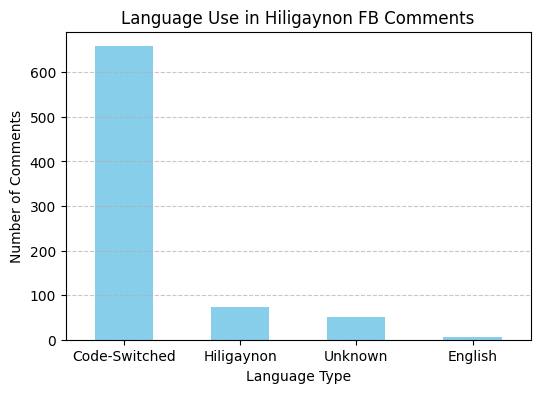

✅ Code-switching analysis saved to fb_comments_with_lang.csv


In [ ]:
# Distribution plot
plt.figure(figsize=(6,4))
comments["lang_usage"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Language Use in Hiligaynon FB Comments")
plt.xlabel("Language Type")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print("✅ Code-switching analysis saved to fb_comments_with_lang.csv")